# Assignment 3 – Large Language Models
Fine-Tuning BERT for Sentiment Analysis on IMDb

## 1. Introduction

This notebook presents an end-to-end implementation of a Large Language Model (LLM) fine-tuning task.
The objective is to perform binary sentiment classification on movie reviews using a pre-trained
BERT-based model. The performance of the fine-tuned LLM is compared against a traditional
machine learning baseline to demonstrate the advantages of contextual language models.


## 2. Environment Setup and Imports

This section installs and imports all required libraries for data handling, model training,
evaluation, and visualisation.


In [2]:
# 0) Install & Imports

!pip -q install datasets transformers evaluate accelerate scikit-learn matplotlib

import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00


## 3. Reproducibility and Device Configuration

To ensure reproducibility, random seeds are fixed across libraries.
The computation device (CPU or GPU) is automatically detected.


In [3]:
# 1) Reproducibility & Device

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 4. Dataset Loading and Exploration

The IMDb movie reviews dataset is loaded from the Hugging Face Datasets library.
The dataset consists of labelled movie reviews for binary sentiment classification
(positive or negative).


In [4]:
# 2) Load Dataset (IMDb)

# IMDb has 50k labelled reviews (train=25k, test=25k), labels: 0=neg, 1=pos
dataset = load_dataset("imdb")
print(dataset)

# Optional: create a validation set from the train split
# We'll take 10% of train as validation
split = dataset["train"].train_test_split(test_size=0.1, seed=SEED)
train_ds = split["train"]
val_ds   = split["test"]
test_ds  = dataset["test"]

print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}, Test size: {len(test_ds)}")

# Quick look at a sample
print("\nSample text:\n", train_ds[0]["text"][:400], "...")
print("Label:", train_ds[0]["label"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Train size: 22500, Val size: 2500, Test size: 25000

Sample text:
 With these people faking so many shots, using old footage, and gassing animals to get them out, not to mention that some of the scenes were filmed on a created set with actors, what's to believe? Old film of countries is nice, but the animal abuse and degradation of natives is painful to watch in these films. I know, racism is OK in these old films, but there is more to that to make this couple lo ...
Label: 0


## 5. Baseline Model: TF-IDF and Logistic Regression

A traditional machine learning baseline is implemented using TF-IDF feature extraction
and Logistic Regression. This baseline provides a performance reference point for evaluating
the benefits of fine-tuning a Large Language Model.


In [5]:
# 3) Baseline Model (TF-IDF + Logistic Regression)

# The baseline model provides a non-neural reference point
# to quantify the performance gain achieved by fine-tuning an LLM.
# Baseline models are fast and help show why BERT helps.
# Trained on train set, validate on val, and report final test performance.

def train_baseline_tfidf_logreg(train_data, val_data, test_data, max_features=50000):
    """
    Train a baseline model using TF-IDF features and Logistic Regression.
    Returns fitted vectorizer, classifier, and predictions for evaluation.
    """
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),
        stop_words="english"
    )

    X_train = vectorizer.fit_transform(train_data["text"])
    y_train = np.array(train_data["label"])

    X_val = vectorizer.transform(val_data["text"])
    y_val = np.array(val_data["label"])

    X_test = vectorizer.transform(test_data["text"])
    y_test = np.array(test_data["label"])

    clf = LogisticRegression(max_iter=2000, n_jobs=None)
    clf.fit(X_train, y_train)

    val_preds = clf.predict(X_val)
    test_preds = clf.predict(X_test)

    return vectorizer, clf, (y_val, val_preds), (y_test, test_preds)

def compute_metrics_sklearn(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

vec, logreg, (y_val_b, val_pred_b), (y_test_b, test_pred_b) = train_baseline_tfidf_logreg(
    train_ds, val_ds, test_ds, max_features=50000
)

baseline_val_metrics = compute_metrics_sklearn(y_val_b, val_pred_b)
baseline_test_metrics = compute_metrics_sklearn(y_test_b, test_pred_b)

print("\nBaseline (TF-IDF + Logistic Regression) - Validation metrics:", baseline_val_metrics)
print("Baseline (TF-IDF + Logistic Regression) - Test metrics:", baseline_test_metrics)
print("\nBaseline classification report (TEST):\n", classification_report(y_test_b, test_pred_b, digits=4))



Baseline (TF-IDF + Logistic Regression) - Validation metrics: {'accuracy': 0.8932, 'precision': 0.8891509433962265, 'recall': 0.8997613365155132, 'f1': 0.8944246737841044}
Baseline (TF-IDF + Logistic Regression) - Test metrics: {'accuracy': 0.88136, 'precision': 0.8812989921612542, 'recall': 0.88144, 'f1': 0.8813694904407647}

Baseline classification report (TEST):
               precision    recall  f1-score   support

           0     0.8814    0.8813    0.8814     12500
           1     0.8813    0.8814    0.8814     12500

    accuracy                         0.8814     25000
   macro avg     0.8814    0.8814    0.8814     25000
weighted avg     0.8814    0.8814    0.8814     25000



## 6. Tokenisation and Text Preprocessing

Text data is tokenised using a BERT tokenizer. Reviews are truncated to a fixed maximum length,
and padding is handled dynamically during batching.


In [6]:
# 4) Tokenization for BERT

# Used a BERT-style tokenizer to convert raw text to input_ids + attention_mask.
# Truncation prevents very long reviews from exceeding max length.
# Padding is handled dynamically by a data collator.

MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 256

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_tok = train_ds.map(tokenize_function, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tokenize_function, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize_function, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/22500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

## 7. Model Architecture: BERT for Sequence Classification

A pre-trained BERT-based model is loaded with an added classification head.
The model outputs class probabilities for binary sentiment prediction.


In [7]:
# 5) Define BERT Model

# AutoModelForSequenceClassification adds a classification head on top of BERT.
# The loss used internally is CrossEntropyLoss for multi-class / binary classification.

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [8]:
# 6) Metrics for Hugging Face Trainer

def compute_metrics_trainer(eval_pred):
    """
    eval_pred is a tuple (logits, labels).
    We convert logits -> predicted labels, then compute accuracy/precision/recall/F1.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")

    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}


## 8. Training Configuration and Hyperparameters

This section defines the training arguments, including learning rate, batch size,
number of epochs, and regularisation settings used for fine-tuning the model.


In [9]:
# 7) Training Arguments (Hyperparameters)

# Hyperparameters are chosen based on standard BERT fine-tuning
# practices reported in the literature to balance performance and stability.

# - learning_rate: controls update step size
# - weight_decay: regularization to reduce overfitting
# - epochs: passes over training data
# - batch size: affects stability and memory usage

training_args = TrainingArguments(
    output_dir="./bert_imdb_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)


## 9. Fine-Tuning the BERT Model

The BERT model is fine-tuned on the training dataset using the Hugging Face Trainer API.
Evaluation is performed at the end of each epoch using the validation dataset.


In [10]:
# 8) Train with Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics_trainer
)

train_output = trainer.train()

/tmp/ipython-input-3848700164.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.280900,0.245909,0.911200,0.913669,0.909308,0.911483
2,0.152700,0.312135,0.911200,0.929461,0.891010,0.909829
3,0.078900,0.393285,0.918000,0.917460,0.919650,0.918554


## 10. Model Evaluation on Test Data

The fine-tuned model is evaluated on a held-out test set.
Performance is measured using accuracy, precision, recall, and F1-score.


In [11]:
# 9) Evaluate on Validation + Test

val_results = trainer.evaluate(eval_dataset=val_tok)
test_results = trainer.evaluate(eval_dataset=test_tok)

print("\nFine-tuned BERT - Validation results:", val_results)
print("Fine-tuned BERT - Test results:", test_results)


Fine-tuned BERT - Validation results: {'eval_loss': 0.39328494668006897, 'eval_accuracy': 0.918, 'eval_precision': 0.9174603174603174, 'eval_recall': 0.9196499602227526, 'eval_f1': 0.9185538339292809, 'eval_runtime': 35.4738, 'eval_samples_per_second': 70.475, 'eval_steps_per_second': 2.227, 'epoch': 3.0}
Fine-tuned BERT - Test results: {'eval_loss': 0.361653208732605, 'eval_accuracy': 0.9198, 'eval_precision': 0.9108918643802365, 'eval_recall': 0.93064, 'eval_f1': 0.9206600451109967, 'eval_runtime': 353.8302, 'eval_samples_per_second': 70.655, 'eval_steps_per_second': 2.21, 'epoch': 3.0}


## 11. Confusion Matrix Analysis

A confusion matrix is computed to analyse class-wise prediction performance
and identify any misclassification patterns.


In [13]:
# 10) Detailed Test Report (BERT)

from sklearn.metrics import confusion_matrix

preds_output = trainer.predict(test_tok)
test_logits = preds_output.predictions
test_labels = preds_output.label_ids
test_preds = np.argmax(test_logits, axis=-1)

print("\nFine-tuned BERT classification report (TEST):\n", classification_report(test_labels, test_preds, digits=4))
print("Confusion matrix (TEST):\n", confusion_matrix(test_labels, test_preds))


Fine-tuned BERT classification report (TEST):
               precision    recall  f1-score   support

           0     0.9291    0.9090    0.9189     12500
           1     0.9109    0.9306    0.9207     12500

    accuracy                         0.9198     25000
   macro avg     0.9200    0.9198    0.9198     25000
weighted avg     0.9200    0.9198    0.9198     25000

Confusion matrix (TEST):
 [[11362  1138]
 [  867 11633]]


## 12. Learning Curves and Overfitting Analysis

Training and validation losses are visualised to assess convergence behaviour
and check for signs of overfitting.


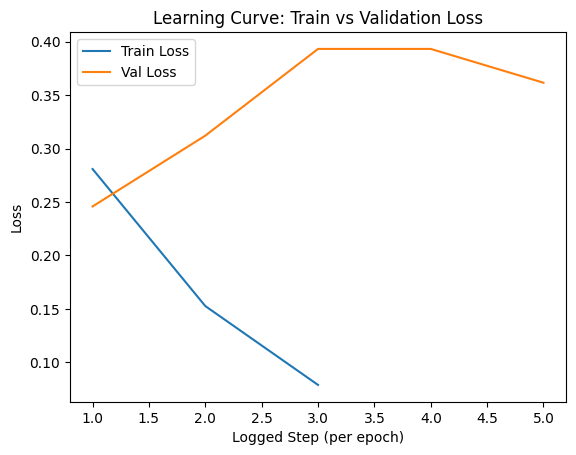

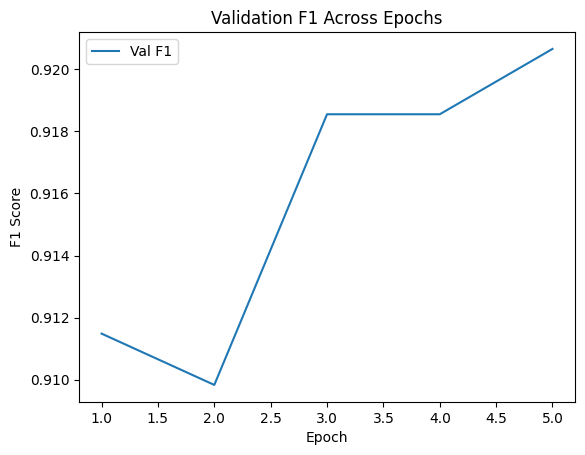

In [14]:
# 11) Learning Curve Plot (Evidence of training / overfitting check)

log_history = trainer.state.log_history

train_losses = []
eval_losses = []
eval_f1s = []
epochs = []

for entry in log_history:
    # training loss entries
    if "loss" in entry and "epoch" in entry and "eval_loss" not in entry:
        train_losses.append(entry["loss"])
        epochs.append(entry["epoch"])
    # evaluation entries
    if "eval_loss" in entry and "epoch" in entry:
        eval_losses.append(entry["eval_loss"])
        # eval f1 might be present depending on trainer logging
        if "eval_f1" in entry:
            eval_f1s.append(entry["eval_f1"])

# Plot losses (train vs val)
plt.figure()
if len(train_losses) > 0:
    plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
if len(eval_losses) > 0:
    plt.plot(range(1, len(eval_losses) + 1), eval_losses, label="Val Loss")
plt.xlabel("Logged Step (per epoch)")
plt.ylabel("Loss")
plt.title("Learning Curve: Train vs Validation Loss")
plt.legend()
plt.show()

# Plot validation F1 across epochs
if len(eval_f1s) > 0:
    plt.figure()
    plt.plot(range(1, len(eval_f1s) + 1), eval_f1s, label="Val F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title("Validation F1 Across Epochs")
    plt.legend()
    plt.show()

## 13. Comparison: Baseline vs Fine-Tuned BERT

The performance of the fine-tuned BERT model is compared against the baseline
TF-IDF + Logistic Regression model to highlight improvements achieved through
contextual language representations.


In [15]:
# 12) Comparison Table (Baseline vs BERT)

def print_comparison(baseline_metrics, bert_metrics, name_baseline="TF-IDF+LogReg", name_bert="Fine-tuned BERT"):
    """
    Print a clean comparison for report writing.
    """
    print("\n================= COMPARISON (TEST) =================")
    print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-" * 62)

    print(f"{name_baseline:<20} "
          f"{baseline_metrics['accuracy']:>10.4f} "
          f"{baseline_metrics['precision']:>10.4f} "
          f"{baseline_metrics['recall']:>10.4f} "
          f"{baseline_metrics['f1']:>10.4f}")

    print(f"{name_bert:<20} "
          f"{bert_metrics['eval_accuracy']:>10.4f} "
          f"{bert_metrics['eval_precision']:>10.4f} "
          f"{bert_metrics['eval_recall']:>10.4f} "
          f"{bert_metrics['eval_f1']:>10.4f}")

print_comparison(baseline_test_metrics, test_results)


================= COMPARISON (TEST) =================
Model                  Accuracy  Precision     Recall         F1
--------------------------------------------------------------
TF-IDF+LogReg            0.8814     0.8813     0.8814     0.8814
Fine-tuned BERT          0.9198     0.9109     0.9306     0.9207


## 14. Summary

This notebook demonstrated the fine-tuning of a Large Language Model for sentiment analysis.
Results show that the BERT-based approach significantly outperforms the traditional baseline,
confirming the effectiveness of LLMs for text classification tasks.
